In [8]:
import Kea
from Kea.utils import plotting
from Kea.simulator import fbm
from Kea.statistics import statistics_base, moments
from Kea.statistics.spectra import strfn_spectra, spectra_base, arevalo_spectra, per_spectra, corr_spectra
from Kea.statistics.statfunc import strfn, statfunc_base, statfunc_mpi_naive, corr
from Kea.fitting import fit_base

c = plotting.COLOR_CYCLE_6

import matplotlib as mpl
plotting.modify_rc()
import matplotlib.pyplot as plt

import numpy as np

import sympy as sp

D = 2
N = 256
L = 5.*np.pi
grid_dims = [N for _ in range(D)]
phys_dims = [L for _ in range(D)]

twopi = 2.*np.pi
dk = twopi/L
dx = L/N


In [9]:
min, max = -(D+2.), -2.
NUM = 5
alphas = np.linspace(max, min, NUM)
np.random.seed(1234)
fields = []
for a in alphas:
    fields.append(fbm.create_fbm(grid_dims, phys_dims, (a,), gfunc='analytical_pow'))
energies = []
for f in fields:
    energies.append(moments.var(f, lenn=phys_dims))
kfeks = []
acfs = []
bin_acfs = []
for i, f in enumerate(fields):
    lv = statfunc_base.get_all_lagvecs([2*n for n in grid_dims])
    acf = corr.process_lags(f, f, lv, lenn=phys_dims, shape=[2*n for n in grid_dims], periodic=True)
    acfs.append(acf)

    lvm = statfunc_base.get_lagvec_magnitude_array([2*n for n in grid_dims]) * dx

    bin_l, bin_acf, w = statistics_base.bin_data(lvm, acf, bin_func=np.nansum,
        cut_excess=True, nan_small=False, ignore_nan=False,
        min_bin=0., bin_loc='center')

    kD, fekD = per_spectra.modal_spectrum(f, phys_dims=phys_dims)
    ko, feko, _ = spectra_base.spectrum_integrate(kD, fekD, spec_type='omni', lenn=phys_dims)
    kfeks.append((ko, feko))

IDX = 2

In [10]:

k = sp.symbols('k', positive=True, real=True)
l = sp.symbols('lambda', positive=True, real=True)

nu = sp.symbols('nu', positive=True, real=True)

a = sp.symbols('alpha', positive=True, real=True)

a = sp.sqrt(sp.pi) * sp.gamma(nu + 1/2)/sp.gamma(nu)
display(a)

E = (2/sp.pi) * (a**2 / (a**2 + k**2))**((1 + 2*nu) / 2)

display(E)

R = sp.integrate(E * sp.cos(k * l), (k, 0, sp.oo))

display(R.simplify())

#R = (2*a)/(sqrt(pi)*gamma(nu + 1/2)) * (1/2 * k * a)**nu * 

S = 2 * sp.limit(R, l, 0) - 2 * R

display(S.simplify())


sqrt(pi)*gamma(nu + 0.5)/gamma(nu)

2*(pi*gamma(nu + 0.5)**2/((k**2 + pi*gamma(nu + 0.5)**2/gamma(nu)**2)*gamma(nu)**2))**(nu + 1/2)/pi

(sqrt(pi)*lambda*nu/(2*gamma(nu + 1)))**nu*(besseli(-nu, sqrt(pi)*lambda*gamma(nu + 0.5)/gamma(nu)) - besseli(nu, sqrt(pi)*lambda*gamma(nu + 0.5)/gamma(nu)))*gamma(1 - nu)*gamma(nu + 0.5)**(nu + 1)/gamma(nu + 1/2)

2**(1 - nu)*((2*gamma(nu + 1))**nu*gamma(nu + 1/2) - (sqrt(pi)*lambda*nu)**nu*besseli(-nu, sqrt(pi)*lambda*gamma(nu + 0.5)/gamma(nu))*gamma(1 - nu)*gamma(nu + 0.5)**(nu + 1) + (sqrt(pi)*lambda*nu)**nu*besseli(nu, sqrt(pi)*lambda*gamma(nu + 0.5)/gamma(nu))*gamma(1 - nu)*gamma(nu + 0.5)**(nu + 1))/(gamma(nu + 1/2)*gamma(nu + 1)**nu)

Text(0.5, 0, '$k$')

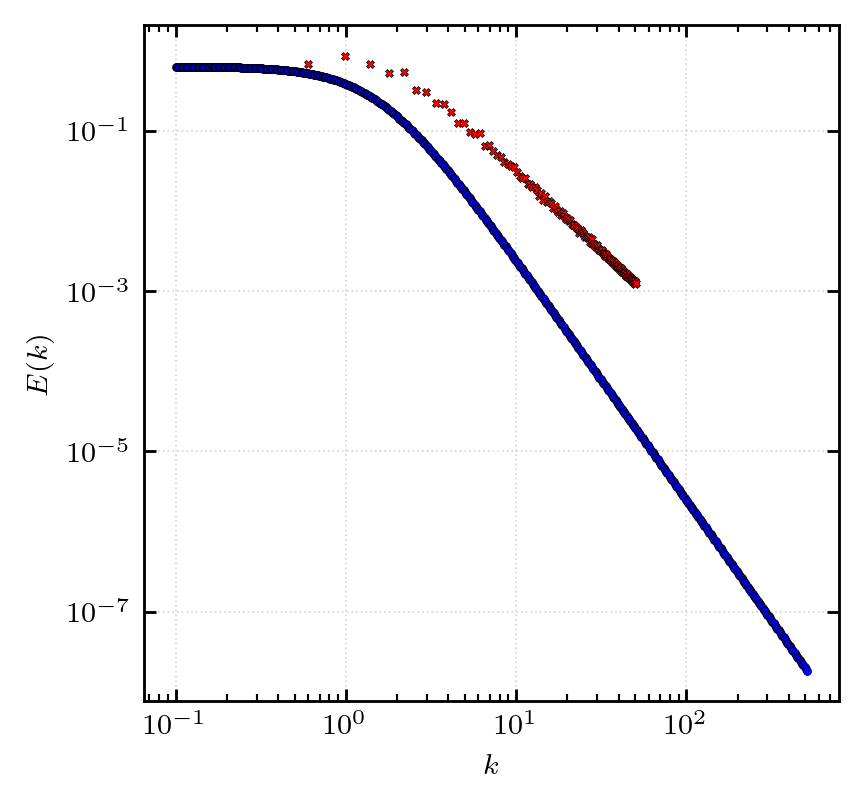

In [11]:

fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

_k = np.exp(np.linspace(np.log(0.1), np.log(512), 512))
_nu = (-alphas[IDX] - 1.) / 2.

for __k in _k:
    val = E.subs({k: __k, nu: _nu}).evalf()
    ax.scatter(__k, val, marker='o', s=5., color='blue', zorder=2, linewidth=0.2, edgecolor='black')

ax.scatter(kfeks[IDX][0], kfeks[IDX][1]/1e2, marker='X', s=5., color='red', zorder=2, linewidth=0.2, edgecolor='black')

ax.loglog()

ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax.set_ylabel(r'$E(k)$')
ax.set_xlabel(r'$k$')
